# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4
import h5netcdf
print(h5netcdf.__version__)
from xarray.backends import list_engines
print("Available engines:", list(list_engines().keys()))
#from xarray.backends.h5netcdf_ import H5NetCDFBackendEntrypoint
import h5netcdf.legacyapi
import scipy
import zarr
import s3fs

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


1.6.4
Available engines: ['netcdf4', 'h5netcdf', 'scipy', 'store', 'zarr']


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3? We are using h5netcdf
2. Why do we need `storage_options={'anon': True}`? Because we are accessing a public dataset on AWS
3. Inspect dataset attributes: what are the units and long name of `sst`? Daily sea surface temperature and units are in Celsius


In [8]:
yearmonth = "202001"  # TODO: try other months like "201507" or "201909"
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
#fs = s3fs.S3FileSystem(anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]


ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds

print(ds.sst.attrs)



Found 31 files for 202001. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202001/oisst-avhrr-v02r01.20200101.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202001/oisst-avhrr-v02r01.20200102.nc']
{'long_name': 'Daily sea surface temperature', 'valid_min': np.int16(-300), 'valid_max': np.int16(4500), 'units': 'Celsius'}


## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space? time and lat, lon, zlev
2. What is the shape of `sst`? (31, 1, 720, 1440)
3. How are missing values represented? NaN


In [14]:
list(ds.data_vars), list(ds.coords)
print(ds.sst.shape)
for key, value in ds.sst.attrs.items():
    print(f"{key}: {value}")
print(f"Contains NaN values: {np.isnan(ds.sst.values).any()}")
print(f"Number of NaN values: {np.isnan(ds.sst.values).sum()}")

(31, 1, 720, 1440)
long_name: Daily sea surface temperature
valid_min: -300
valid_max: 4500
units: Celsius
Contains NaN values: True
Number of NaN values: 10715150


## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose? Indian ocean - 40, 100 for lon and -30,20 for lat
2. How many daily steps are present in this month? 31 steps


In [16]:
var = "sst"

lon_min, lon_max = 40, 100   # TODO
lat_min, lat_max =  -30,  20   # TODO

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 31, zlev: 1, lat: 200, lon: 240)> Size: 6MB
dask.array<getitem, shape=(31, 1, 200, 240), dtype=float32, chunksize=(1, 1, 200, 240), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01T12:00:00 ... 2020-01-31T12...
  * lat      (lat) float32 800B -29.88 -29.62 -29.38 ... 19.38 19.62 19.88
  * lon      (lon) float32 960B 40.12 40.38 40.62 40.88 ... 99.38 99.62 99.88
  * zlev     (zlev) float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    valid_min:  -300
    valid_max:  4500
    units:      Celsius

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation? Monthly average SST: 27.9 C, std: 0.06 C
2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies? Largest anomaly is 0.12 C, smallest anomaly is -0.14 C
3. What day had the warmest/coolest region-mean SST? Warmest SST: 2020-01-24. Coolest SST: 2020-01-01


Month mean SST (°C): 27.868789672851562
Month std SST (°C): 0.06453724205493927


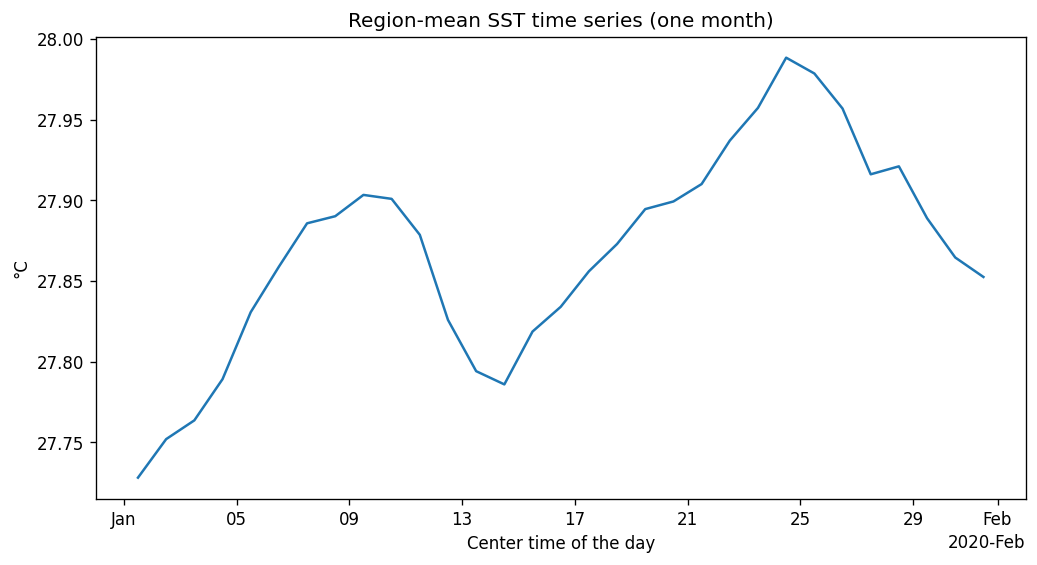

Warmest day: 2020-01-24 27.98831558227539
Coolest day: 2020-01-01 27.728116989135742


/tmp/ipykernel_889929/66363328.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
/tmp/ipykernel_889929/66363328.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [22]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

# # within month anomalies
# sst_anomalies = ds.sst - ts_mean
# max_anomaly = sst_anomalies.max()
# min_anomaly = sst_anomalies.min()
# print("max anomaly: ", max_anomaly)
# print("min_anomaly: ", min_anomaly)

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.11952296644449234
Min anomaly (°C): -0.14066894352436066


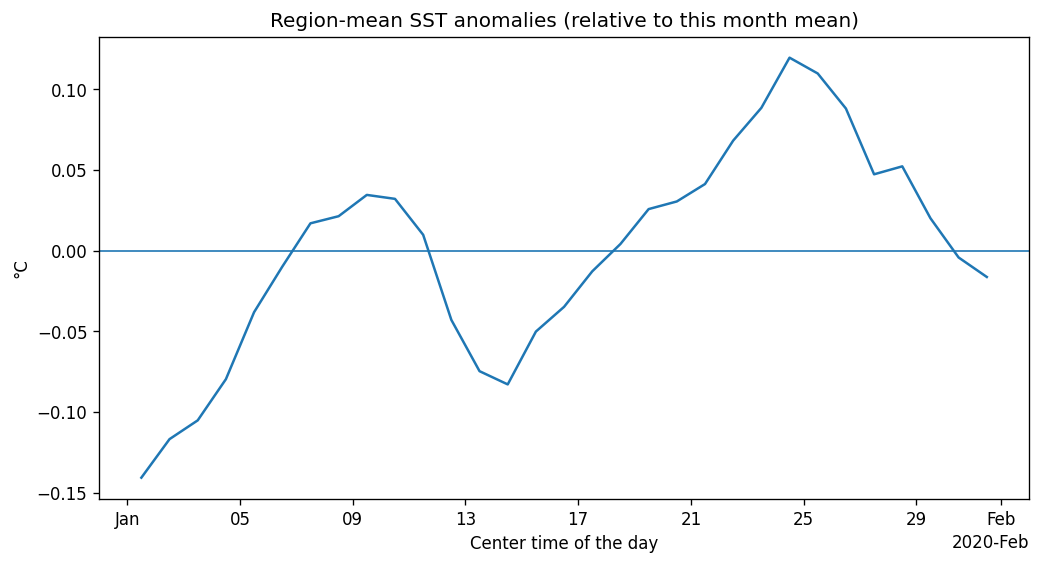

In [18]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice? The SST near the eqautor are higher and have less variablility.
2. Where is variability strongest? Variability is the strongest as you go away from the equator and away from shore.


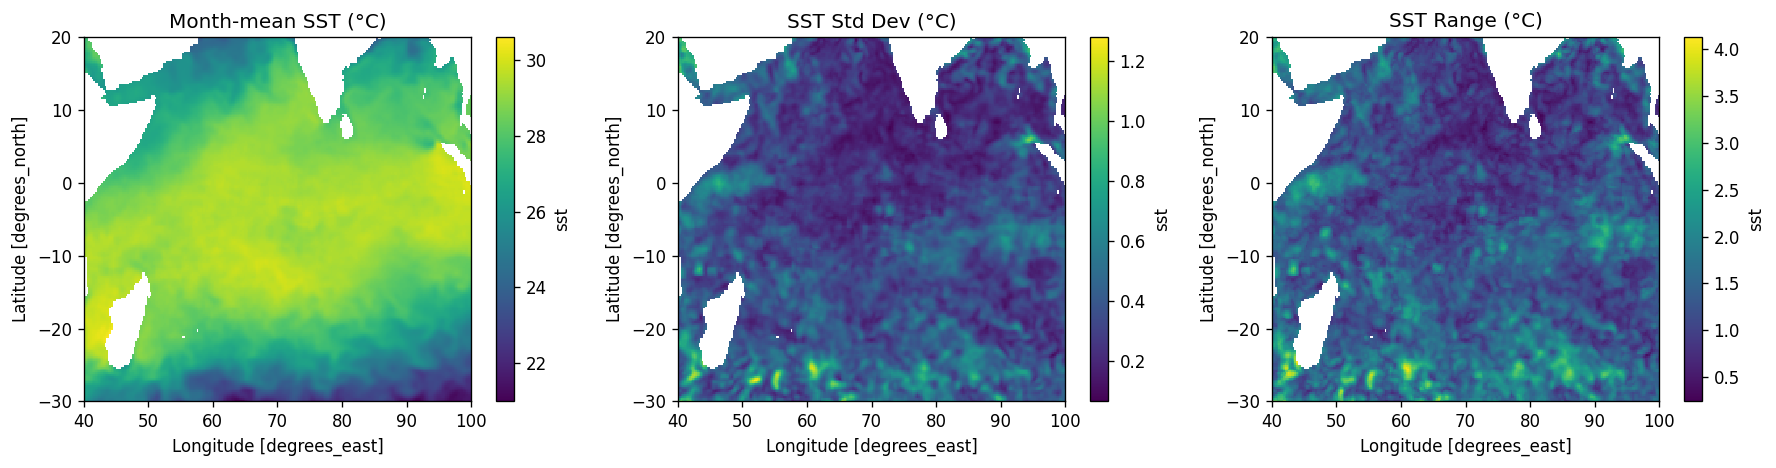

In [19]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

For this question I used a subset of SST data in the Indian Ocean